In [ ]:
# ================================================================
# COFFEE BEAN QC — LIGHTWEIGHT PIPELINE v5.5
# ================================================================
# Perubahan dari v5.4:
#   [NEW] Cache dataset (JPEG 512px) di-zip → bisa didownload
#         Jalankan ulang: load zip, skip preprocessing (~169x lebih cepat)
#
# Struktur file output:
#   /kaggle/working/
#     cache_dataset/        ← hasil preprocessing (JPEG)
#     cache_dataset.zip     ← zip untuk didownload
#     best_*.pth            ← bobot model per model
#
# Dataset:
#   TRAIN : /kaggle/input/datasets/sot2542/coffee-bean-dataset-v2/train/
#   TEST  : /kaggle/input/datasets/sot2542/coffee-bean-dataset-v2/test/
# ================================================================

In [ ]:

# !pip install timm -q

import os, time, copy, random, shutil, zipfile
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, precision_recall_fscore_support,
    classification_report,
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True


In [ ]:


# ================================================================
# 1. KONFIGURASI
# ================================================================
TRAIN_DIR_ORIG = "/kaggle/input/datasets/sot2542/coffee-bean-dataset-v2/train"
TEST_DIR_ORIG  = "/kaggle/input/datasets/sot2542/coffee-bean-dataset-v2/test"

CACHE_ROOT    = "/kaggle/input/datasets/mocharizal/cache-dataset/cache_dataset"
CACHE_ZIP     = "/kaggle/working/cache_dataset.zip"
TRAIN_DIR     = os.path.join(CACHE_ROOT, "train")
TEST_DIR      = os.path.join(CACHE_ROOT, "test")

CACHE_MAX_SIZE = 512
CACHE_QUALITY  = 92
CACHE_WORKERS  = 4

IMG_SIZE     = 224
BATCH_SIZE   = 64
EPOCHS       = 35
LR           = 3e-4
MIN_LR       = 1e-6
WEIGHT_DECAY = 1e-4
PATIENCE     = 10
VAL_RATIO    = 0.15
MIXUP_ALPHA  = 0.4
CUTMIX_ALPHA = 0.3
SEED         = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CLASS_NAMES  = ["Dark", "Green", "Light", "Medium"]
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = dict(enumerate(CLASS_NAMES))

LIGHTING_CONDITIONS = [
    "Lightbox", "Lightbox + Bottle",
    "NaturalLight", "NaturalLight + Bottle",
]
LC_SHORT = ["Lightbox", "LB+Bottle", "NatLight", "NL+Bottle"]
LC_COLS  = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

ROAST_COLORS = {
    "Dark": "#3d1f0a", "Green": "#4a7c2f",
    "Light": "#c17f4a", "Medium": "#7a3d1e",
}
ROAST_INFO = {
    "Dark":   {"suhu": "225-230C", "rasa": "Pahit kuat, smoky, bold",   "produk": "Kopi tubruk, cold brew"},
    "Green":  {"suhu": "Tidak disangrai", "rasa": "Herbal, berumput",   "produk": "Green coffee extract"},
    "Light":  {"suhu": "180-205C", "rasa": "Fruity, floral, asam",      "produk": "Pour-over, V60, Chemex"},
    "Medium": {"suhu": "210-220C", "rasa": "Seimbang, caramel",         "produk": "Espresso, cappuccino"},
}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

MODEL_CONFIGS = {
    "EfficientNet-B0":   {"timm_name": "efficientnet_b0",       "feat_dim": 0, "input_size": 224, "is_vit": False, "note": "Baseline, MBConv+SE"},
    "MobileNetV3-Large": {"timm_name": "mobilenetv3_large_100", "feat_dim": 0, "input_size": 224, "is_vit": False, "note": "SE+h-swish, NAS"},
    "MobileViT-XS":      {"timm_name": "mobilevit_xs",          "feat_dim": 0, "input_size": 256, "is_vit": False, "note": "CNN+Transformer hybrid"},
    "GhostNet-100":      {"timm_name": "ghostnet_100",          "feat_dim": 0, "input_size": 224, "is_vit": False, "note": "Ghost modules, hemat FLOPs"},
    "RegNetY-400MF":     {"timm_name": "regnety_004",           "feat_dim": 0, "input_size": 224, "is_vit": False, "note": "Facebook, Pareto-optimal"},
}

print("=" * 68)
print("  COFFEE BEAN QC — PIPELINE v5.5")
print("=" * 68)
print(f"  Device : {DEVICE}" + (f"  ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print(f"  Train  : {TRAIN_DIR_ORIG}")
print(f"  Test   : {TEST_DIR_ORIG}")
print(f"  Cache  : {CACHE_ROOT}")
print(f"  Zip    : {CACHE_ZIP}  ← download setelah selesai")
print("=" * 68)



In [ ]:

# ================================================================
# 2. PREPROCESSING — PNG → JPEG 512px + ZIP EXPORT
# ================================================================
print("\n[2] Preprocessing...")

def resize_and_cache(src: str, dst: str, max_size: int, quality: int) -> bool:
    try:
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        if os.path.exists(dst):
            return True
        img = Image.open(src).convert("RGB")
        w, h = img.size
        if max(w, h) > max_size:
            s = max_size / max(w, h)
            img = img.resize((int(w*s), int(h*s)), Image.LANCZOS)
        img.save(dst, "JPEG", quality=quality, optimize=True)
        return True
    except Exception as e:
        print(f"  WARN {src}: {e}")
        return False


def preprocess_split(src_root: str, dst_root: str, label: str) -> int:
    if not os.path.isdir(src_root):
        print(f"  [{label}] Tidak ditemukan: {src_root}, skip.")
        os.makedirs(dst_root, exist_ok=True)
        return 0

    IMG_EXTS = {".png", ".PNG", ".jpg", ".JPG", ".jpeg", ".JPEG"}
    tasks = []

    # Strategi 1: nested {lighting}/{class}/
    for lc in LIGHTING_CONDITIONS:
        for cls in CLASS_NAMES:
            src_cls = os.path.join(src_root, lc, cls)
            if not os.path.isdir(src_cls): continue
            dst_cls = os.path.join(dst_root, lc, cls)
            os.makedirs(dst_cls, exist_ok=True)
            for f in os.listdir(src_cls):
                if os.path.splitext(f)[1] not in IMG_EXTS: continue
                tasks.append((
                    os.path.join(src_cls, f),
                    os.path.join(dst_cls, os.path.splitext(f)[0] + ".jpg")
                ))

    # Strategi 2: recursive fallback (test flat)
    if not tasks:
        print(f"  [{label}] Nested=0, recursive scan...")
        for dirpath, _, fnames in os.walk(src_root):
            for f in fnames:
                if os.path.splitext(f)[1] not in IMG_EXTS: continue
                rel = os.path.relpath(dirpath, src_root)
                dst_dir = os.path.join(dst_root, rel)
                os.makedirs(dst_dir, exist_ok=True)
                tasks.append((
                    os.path.join(dirpath, f),
                    os.path.join(dst_dir, os.path.splitext(f)[0] + ".jpg")
                ))

    if not tasks:
        print(f"  [{label}] Tidak ada gambar ditemukan.")
        os.makedirs(dst_root, exist_ok=True)
        return 0

    done = failed = 0
    t0 = time.time()
    print(f"  [{label}] {len(tasks)} gambar → konversi JPEG {CACHE_MAX_SIZE}px...")

    with ThreadPoolExecutor(max_workers=CACHE_WORKERS) as ex:
        futures = {ex.submit(resize_and_cache, s, d, CACHE_MAX_SIZE, CACHE_QUALITY): (s, d)
                   for s, d in tasks}
        for fut in as_completed(futures):
            if fut.result(): done += 1
            else: failed += 1
            if done % 500 == 0 and done > 0:
                elapsed = time.time() - t0
                print(f"    {done}/{len(tasks)}  {done/elapsed:.0f} img/s  ETA {(len(tasks)-done)/max(done/elapsed,1):.0f}s")

    mb = sum(os.path.getsize(os.path.join(r,f))
             for r,_,fs in os.walk(dst_root) for f in fs) / 1e6
    print(f"  [{label}] Selesai: {done} OK, {failed} gagal | {time.time()-t0:.0f}s | {mb:.0f} MB")
    return done


def zip_cache(cache_root: str, zip_path: str):
    """Zip seluruh cache folder → bisa didownload."""
    if os.path.exists(zip_path):
        os.remove(zip_path)
    print(f"\n  Membuat zip cache: {zip_path}")
    t0 = time.time()
    n  = 0
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED, compresslevel=1) as zf:
        for dirpath, _, fnames in os.walk(cache_root):
            for fname in fnames:
                full = os.path.join(dirpath, fname)
                arc  = os.path.relpath(full, os.path.dirname(cache_root))
                zf.write(full, arc)
                n += 1
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f"  Zip selesai: {n} file | {size_mb:.0f} MB | {time.time()-t0:.0f}s")
    print(f"  ✅ Download: {zip_path}")


def load_from_zip(zip_path: str, extract_to: str):
    """Ekstrak zip cache → skip preprocessing."""
    print(f"  Ekstrak {zip_path} → {extract_to}")
    t0 = time.time()
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_to)
    print(f"  Ekstrak selesai: {time.time()-t0:.0f}s")


# ── Logic preprocessing ──────────────────────────────────────
zip_exists   = os.path.exists(CACHE_ZIP)
cache_exists = (os.path.isdir(TRAIN_DIR) and
                any(True for _,_,fs in os.walk(TRAIN_DIR) for f in fs if f.endswith('.jpg')))

if cache_exists:
    n = sum(1 for _,_,fs in os.walk(CACHE_ROOT) for f in fs if f.endswith('.jpg'))
    print(f"  Cache sudah ada ({n} file JPEG). Skip preprocessing.")
    if zip_exists:
        print(f"  Zip sudah ada: {CACHE_ZIP}")
    else:
        zip_cache(CACHE_ROOT, CACHE_ZIP)

elif zip_exists:
    print(f"  Zip ditemukan. Ekstrak langsung (skip preprocessing)...")
    os.makedirs(os.path.dirname(CACHE_ROOT), exist_ok=True)
    load_from_zip(CACHE_ZIP, os.path.dirname(CACHE_ROOT))

else:
    print(f"  Mulai preprocessing PNG → JPEG...")
    t_start = time.time()
    preprocess_split(TRAIN_DIR_ORIG, TRAIN_DIR, "TRAIN")
    preprocess_split(TEST_DIR_ORIG,  TEST_DIR,  "TEST")
    total_min = (time.time() - t_start) / 60
    total_mb  = sum(os.path.getsize(os.path.join(r,f))
                    for r,_,fs in os.walk(CACHE_ROOT) for f in fs) / 1e6
    print(f"\n  Preprocessing selesai: {total_min:.1f} mnt | {total_mb:.0f} MB")
    print(f"  (dari ~80.000 MB PNG = {80000/max(total_mb,1):.0f}x lebih kecil)")
    # Buat zip untuk download
    zip_cache(CACHE_ROOT, CACHE_ZIP)

# ── Fallback test ────────────────────────────────────────────
test_cache_ok = os.path.isdir(TEST_DIR) and any(
    True for _,_,fs in os.walk(TEST_DIR) for f in fs
    if f.lower().endswith(('.jpg','.jpeg','.png'))
)
if not test_cache_ok:
    print(f"\n  [INFO] Test cache kosong → fallback ke folder original: {TEST_DIR_ORIG}")
    TEST_DIR = TEST_DIR_ORIG

print(f"\n  Training membaca dari : {TRAIN_DIR}")
print(f"  Test membaca dari     : {TEST_DIR}")



In [ ]:

# ================================================================
# 3. SCAN DATASET
# ================================================================
print("\n[3] Scan dataset...")

def scan_dir(root_dir: str, label: str) -> tuple:
    if not os.path.isdir(root_dir):
        print(f"  [{label}] Tidak ditemukan: {root_dir}")
        return {lc: {c: 0 for c in CLASS_NAMES} for lc in LIGHTING_CONDITIONS}, 0

    IMG_EXTS = ('.jpg', '.jpeg', '.png')
    is_nested = any(os.path.isdir(os.path.join(root_dir, lc)) for lc in LIGHTING_CONDITIONS)
    print(f"\n  [{label}] {root_dir}  ({'nested' if is_nested else 'flat'})")

    if is_nested:
        counts = {}; total = 0
        print(f"  {'Lighting':<28} {'Dark':>6} {'Green':>6} {'Light':>6} {'Medium':>6} {'Total':>7}")
        print(f"  {'-'*62}")
        for lc in LIGHTING_CONDITIONS:
            counts[lc] = {}
            for cls in CLASS_NAMES:
                p = os.path.join(root_dir, lc, cls)
                counts[lc][cls] = len([f for f in os.listdir(p) if f.lower().endswith(IMG_EXTS)]) if os.path.isdir(p) else 0
            row = [counts[lc][c] for c in CLASS_NAMES]; s = sum(row); total += s
            print(f"  {lc:<28}" + "".join(f"{v:>6}" for v in row) + f"  {s:>5}")
        print(f"  {'Total':<28}" + " "*24 + f"  {total:>5}")
        return counts, total
    else:
        cls_counts = {c: 0 for c in CLASS_NAMES}; unknown = 0
        for fname in os.listdir(root_dir):
            if not fname.lower().endswith(IMG_EXTS): continue
            cls = os.path.splitext(fname)[0].split(" ")[0].strip()
            if cls in cls_counts: cls_counts[cls] += 1
            else: unknown += 1
        total = sum(cls_counts.values())
        print(f"  {'Kelas':<10} {'Jumlah':>8}")
        print(f"  {'-'*20}")
        for c in CLASS_NAMES: print(f"  {c:<10} {cls_counts[c]:>8}")
        if unknown: print(f"  {'(unknown)':<10} {unknown:>8}")
        print(f"  {'Total':<10} {total:>8}")
        counts = {lc: {c: 0 for c in CLASS_NAMES} for lc in LIGHTING_CONDITIONS}
        counts["Lightbox"] = cls_counts
        return counts, total

train_counts, total_train = scan_dir(TRAIN_DIR, "TRAIN")
test_counts,  total_test  = scan_dir(TEST_DIR,  "TEST")
print(f"\n  Train: {total_train} | Test: {total_test}")



In [ ]:

# ================================================================
# 4. AUTO-DETECT FEAT_DIM
# ================================================================
print("\n[4] Auto-detect feat_dim...")
print(f"  {'Model':<20} {'timm_name':<28} {'feat_dim':>10}")
print(f"  {'-'*62}")

def detect_feat_dim(timm_name, input_size, is_vit):
    with torch.no_grad():
        bb = timm.create_model(timm_name, pretrained=False,
                               num_classes=0, **({"img_size": 224} if is_vit else {}))
        bb.eval()
        feat = bb(torch.zeros(1, 3, input_size, input_size)).shape[1]
        del bb
    return feat

for name, cfg in MODEL_CONFIGS.items():
    try:
        fd = detect_feat_dim(cfg["timm_name"], cfg["input_size"], cfg["is_vit"])
        MODEL_CONFIGS[name]["feat_dim"] = fd
        print(f"  {name:<20} {cfg['timm_name']:<28} {fd:>10}  OK")
    except Exception as e:
        print(f"  {name:<20} ERROR: {e}")
torch.cuda.empty_cache()



In [ ]:

# ================================================================
# 5. DATASET
# ================================================================
class CoffeeBeanDataset(Dataset):
    """Auto-detect nested (train) vs flat (test) structure."""
    def __init__(self, root_dir, transform=None, preloaded_samples=None):
        self.root_dir  = root_dir
        self.transform = transform
        if preloaded_samples is not None:
            self.samples = preloaded_samples; return

        IMG_EXTS  = ('.jpg', '.jpeg', '.png')
        is_nested = any(os.path.isdir(os.path.join(root_dir, lc)) for lc in LIGHTING_CONDITIONS)
        self.samples = []

        if is_nested:
            for lc in LIGHTING_CONDITIONS:
                for cls in CLASS_NAMES:
                    p = os.path.join(root_dir, lc, cls)
                    if not os.path.isdir(p): continue
                    for f in sorted(os.listdir(p)):
                        if f.lower().endswith(IMG_EXTS):
                            self.samples.append({"path": os.path.join(p, f), "label": CLASS_TO_IDX[cls],
                                                 "class": cls, "lighting": lc, "fname": f})
        else:
            for f in sorted(os.listdir(root_dir)):
                if not f.lower().endswith(IMG_EXTS): continue
                cls = os.path.splitext(f)[0].split(" ")[0].strip()
                if cls not in CLASS_TO_IDX: continue
                self.samples.append({"path": os.path.join(root_dir, f), "label": CLASS_TO_IDX[cls],
                                     "class": cls, "lighting": "Flat", "fname": f})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        item = self.samples[idx]
        img  = Image.open(item["path"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, item["label"]
    @property
    def labels(self): return [s["label"] for s in self.samples]
    @property
    def lightings(self): return [s["lighting"] for s in self.samples]



In [ ]:

# ================================================================
# 6. SPLIT TRAIN/VAL
# ================================================================
print("\n[6] Stratified split Train/Val (85/15)...")
master_train = CoffeeBeanDataset(TRAIN_DIR)
master_test  = CoffeeBeanDataset(TEST_DIR)

by_class = defaultdict(list)
for i, s in enumerate(master_train.samples):
    by_class[s["label"]].append(i)

train_idx, val_idx = [], []
for cls_id, idxs in sorted(by_class.items()):
    random.shuffle(idxs)
    n_val = int(len(idxs) * VAL_RATIO)
    val_idx.extend(idxs[:n_val]); train_idx.extend(idxs[n_val:])
assert not (set(train_idx) & set(val_idx))

train_lbl = [master_train.samples[i]["label"] for i in train_idx]
test_lbl  = master_test.labels
cls_count = np.bincount(train_lbl, minlength=NUM_CLASSES)
print(f"  Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(master_test)}")
print(f"  Per kelas train: {dict(zip(CLASS_NAMES, cls_count))}")



In [ ]:

# ================================================================
# 7. TRANSFORM + DATALOADER
# ================================================================
def make_transforms(input_size):
    crop = int(input_size * 1.15)
    tr_tf = transforms.Compose([
        transforms.Resize((crop, crop)), transforms.RandomCrop(input_size),
        transforms.RandomHorizontalFlip(0.5), transforms.RandomVerticalFlip(0.3),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
        transforms.RandomGrayscale(0.02), transforms.RandAugment(num_ops=2, magnitude=7),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
    ])
    v_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return tr_tf, v_tf

default_train_tf, default_val_tf = make_transforms(IMG_SIZE)
cls_weight     = 1.0 / np.maximum(cls_count, 1).astype(float)
sample_weights = [cls_weight[l] for l in train_lbl]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

def make_loaders(input_size):
    tr_tf, v_tf = make_transforms(input_size)
    tr_ds = CoffeeBeanDataset(TRAIN_DIR, tr_tf, [master_train.samples[i] for i in train_idx])
    va_ds = CoffeeBeanDataset(TRAIN_DIR, v_tf,  [master_train.samples[i] for i in val_idx])
    te_ds = CoffeeBeanDataset(TEST_DIR,  v_tf)
    return (DataLoader(tr_ds, BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True, drop_last=True),
            DataLoader(va_ds, BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True),
            DataLoader(te_ds, BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True),
            te_ds)

train_loader, val_loader, test_loader, test_ds_default = make_loaders(IMG_SIZE)



In [ ]:

# ================================================================
# 8. EDA
# ================================================================
print("\n[8] EDA...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("EDA — Coffee Bean Dataset V2", fontsize=13, fontweight='bold')

mat_tr = np.array([[train_counts[lc][c] for c in CLASS_NAMES] for lc in LIGHTING_CONDITIONS])
sns.heatmap(mat_tr, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=CLASS_NAMES, yticklabels=LC_SHORT,
            linewidths=0.5, annot_kws={"size": 12}, ax=axes[0])
axes[0].set_title(f"TRAIN — {total_train} gambar", fontweight='bold')

mat_te = np.array([[test_counts[lc][c] for c in CLASS_NAMES] for lc in LIGHTING_CONDITIONS])
if mat_te.sum() > 0:
    sns.heatmap(mat_te, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=LC_SHORT,
                linewidths=0.5, annot_kws={"size": 12}, ax=axes[1])
    axes[1].set_title(f"TEST — {total_test} gambar", fontweight='bold')
else:
    axes[1].text(0.5, 0.5, f"Test: {total_test} gambar (flat)",
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].axis("off")

axes[2].pie([len(train_idx), len(val_idx), len(master_test)],
            labels=[f"Train\n{len(train_idx)}", f"Val\n{len(val_idx)}", f"Test\n{len(master_test)}"],
            colors=["#3498db", "#e67e22", "#e74c3c"],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title(f"Split — Total: {total_train+total_test}", fontweight='bold')

plt.tight_layout()
plt.savefig("eda_v5.png", dpi=150, bbox_inches='tight')
plt.show()
print("  eda_v5.png OK")



In [ ]:


# ================================================================
# 9. MODEL
# ================================================================
print("\n[9] Model...")

class CoffeeClassifier(nn.Module):
    def __init__(self, backbone_name, feat_dim, num_classes, is_vit=False):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=True, num_classes=0,
            **({"img_size": 224} if is_vit else {})
        )
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Dropout(0.3),
            nn.Linear(feat_dim, 256), nn.GELU(),
            nn.Dropout(0.2), nn.Linear(256, num_classes),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))

print(f"\n  {'Model':<20} {'feat_dim':>9} {'Params':>10}  Input")
print(f"  {'-'*54}")
for name, cfg in MODEL_CONFIGS.items():
    try:
        m   = CoffeeClassifier(cfg["timm_name"], cfg["feat_dim"], NUM_CLASSES, cfg["is_vit"]).to(DEVICE)
        tot = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"  {name:<20} {cfg['feat_dim']:>9} {tot/1e6:>8.2f}M  {cfg['input_size']}px")
        del m
    except Exception as e:
        print(f"  {name:<20} ERROR: {e}")
torch.cuda.empty_cache()



In [ ]:

# ================================================================
# 10. MIXUP + CUTMIX
# ================================================================
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def cutmix_data(x, y, alpha=CUTMIX_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    rw = int(W * np.sqrt(1-lam)); rh = int(H * np.sqrt(1-lam))
    cx = np.random.randint(W);    cy = np.random.randint(H)
    x1,x2 = max(0,cx-rw//2), min(W,cx+rw//2)
    y1,y2 = max(0,cy-rh//2), min(H,cy+rh//2)
    mixed = x.clone(); mixed[:,:,y1:y2,x1:x2] = x[idx,:,y1:y2,x1:x2]
    return mixed, y, y[idx], 1-(x2-x1)*(y2-y1)/(W*H)

def mixed_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred, ya) + (1-lam)*crit(pred, yb)




In [ ]:
# ================================================================
# 11. TRAINING
# ================================================================
print("\n[11] Training...")

def train_one_model(model_name, cfg):
    print(f"\n  {'='*60}\n  {model_name} | feat_dim={cfg['feat_dim']} | {cfg['input_size']}px\n  {'='*60}")
    tr_ld, va_ld, te_ld, te_ds_m = make_loaders(cfg["input_size"])
    model     = CoffeeClassifier(cfg["timm_name"], cfg["feat_dim"], NUM_CLASSES, cfg["is_vit"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=MIN_LR)
    history   = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "lr":[]}
    best_acc  = 0.0; best_w = None; pat = 0; t0 = time.time()

    for epoch in range(EPOCHS):
        model.train(); t_loss=t_cor=t_n=0
        for imgs, labels in tr_ld:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            r = random.random()
            if r < 0.33:   imgs, ya, yb, lam = mixup_data(imgs, labels);  use_mix=True
            elif r < 0.66: imgs, ya, yb, lam = cutmix_data(imgs, labels); use_mix=True
            else:          use_mix=False
            optimizer.zero_grad()
            out  = model(imgs)
            loss = mixed_criterion(criterion, out, ya, yb, lam) if use_mix else criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            with torch.no_grad():
                t_loss += loss.item()*imgs.size(0); t_cor += (out.argmax(1)==labels).sum().item(); t_n += imgs.size(0)
        scheduler.step()

        model.eval(); v_loss=v_cor=v_n=0
        with torch.no_grad():
            for imgs, labels in va_ld:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                v_loss += criterion(out,labels).item()*imgs.size(0)
                v_cor  += (out.argmax(1)==labels).sum().item(); v_n += imgs.size(0)

        tr_a=t_cor/t_n; va_a=v_cor/v_n; cur_lr=optimizer.param_groups[0]['lr']
        history["train_loss"].append(t_loss/t_n); history["val_loss"].append(v_loss/v_n)
        history["train_acc"].append(tr_a);         history["val_acc"].append(va_a)
        history["lr"].append(cur_lr)

        is_best = va_a > best_acc
        if is_best:
            best_acc=va_a; best_w=copy.deepcopy(model.state_dict()); pat=0
            torch.save(best_w, f"best_{model_name}.pth")
        else:
            pat += 1
        if (epoch+1)%5==0 or is_best:
            print(f"    Ep[{epoch+1:02d}/{EPOCHS}]  Train {tr_a*100:.2f}%  Val {va_a*100:.2f}%  LR {cur_lr:.1e}{'  BEST' if is_best else ''}")
        if pat >= PATIENCE:
            print(f"    Early stop @ ep {epoch+1}"); break

    model.load_state_dict(best_w)
    print(f"\n    Best Val: {best_acc*100:.2f}%  |  {(time.time()-t0)/60:.1f} mnt")
    return history, best_acc, model, te_ld, te_ds_m

all_histories={};all_best_accs={};all_models_map={};all_te_loaders={};all_te_ds_map={}
for mname, mcfg in MODEL_CONFIGS.items():
    hist, bacc, mdl, te_ld, te_obj = train_one_model(mname, mcfg)
    all_histories[mname]=hist; all_best_accs[mname]=bacc
    all_models_map[mname]=mdl; all_te_loaders[mname]=te_ld; all_te_ds_map[mname]=te_obj
    torch.cuda.empty_cache()

print("\n" + "="*55 + "\n  RINGKASAN VAL ACCURACY\n" + "="*55)
for nm, ac in sorted(all_best_accs.items(), key=lambda x: -x[1]):
    print(f"  {nm:<20} {'='*int(ac*40)} {ac*100:.2f}%")



In [ ]:

# ================================================================
# 12. TTA
# ================================================================
def tta_predict(model, img_pil, n_aug=5):
    tta_tf = transforms.Compose([
        transforms.Resize((260,260)), transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(), transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    model.eval(); probs=[]
    with torch.no_grad():
        t = default_val_tf(img_pil).unsqueeze(0).to(DEVICE)
        probs.append(torch.softmax(model(t),1).cpu().numpy())
        for _ in range(n_aug-1):
            t = tta_tf(img_pil).unsqueeze(0).to(DEVICE)
            probs.append(torch.softmax(model(t),1).cpu().numpy())
    return np.mean(probs, axis=0)[0]



In [ ]:

# ================================================================
# 13. EVALUASI
# ================================================================
print(f"\n[13] Evaluasi test set...")

def evaluate_model(model, te_ds_obj, use_tta=False):
    model.eval(); preds=[]; labels_all=[]; probs_all=[]
    if use_tta:
        for s in te_ds_obj.samples:
            img=Image.open(s["path"]).convert("RGB"); pr=tta_predict(model,img)
            probs_all.append(pr); preds.append(int(pr.argmax())); labels_all.append(s["label"])
    else:
        te_ld = DataLoader(te_ds_obj, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        with torch.no_grad():
            for imgs,lbls in te_ld:
                out=model(imgs.to(DEVICE)); pr=torch.softmax(out,1).cpu().numpy()
                probs_all.extend(pr); preds.extend(out.argmax(1).cpu().numpy().tolist()); labels_all.extend(lbls.numpy().tolist())
    p,l,pr = np.array(preds),np.array(labels_all),np.array(probs_all)
    prec,rec,f1,_ = precision_recall_fscore_support(l,p,average=None,labels=range(NUM_CLASSES))
    return dict(preds=p,labels=l,probs=pr,oa=accuracy_score(l,p),ba=balanced_accuracy_score(l,p),precision=prec,recall=rec,f1=f1)

def benchmark_speed(model, n=100):
    model.eval()
    d1=torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(DEVICE); d32=torch.randn(32,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        for _ in range(10): _=model(d1)
    t0=time.perf_counter()
    with torch.no_grad():
        for _ in range(n): _=model(d1)
    lat=(time.perf_counter()-t0)/n*1000
    t0=time.perf_counter()
    with torch.no_grad():
        for _ in range(n): _=model(d32)
    fps=32*n/(time.perf_counter()-t0)
    return dict(latency_ms=lat,throughput=fps,params_m=sum(p.numel() for p in model.parameters())/1e6)

all_res_std={};all_res_tta={};all_benchmarks={}
for mname in MODEL_CONFIGS:
    model=all_models_map[mname]; te_obj=all_te_ds_map[mname]
    print(f"  {mname}...",end="",flush=True)
    rs=evaluate_model(model,te_obj,False); rt=evaluate_model(model,te_obj,True); bm=benchmark_speed(model)
    all_res_std[mname]=rs; all_res_tta[mname]=rt; all_benchmarks[mname]=bm
    print(f"  Std {rs['oa']*100:.2f}%  TTA {rt['oa']*100:.2f}%  {bm['latency_ms']:.1f}ms")

best_model_name = max(all_res_tta, key=lambda n: all_res_tta[n]["oa"])
best_res        = all_res_tta[best_model_name]

print("\n" + "="*72)
print(f"  SCORECARD — TEST SET RESMI ({total_test} gambar)")
print("="*72)
print(f"  {'Model':<20} {'Std':>8} {'TTA':>8} {'Balanced':>10} {'F1':>8} {'ms':>6}")
print(f"  {'-'*66}")
for nm in sorted(all_res_tta, key=lambda n: -all_res_tta[n]["oa"]):
    rs,rt,bm=all_res_std[nm],all_res_tta[nm],all_benchmarks[nm]
    star=" BEST" if nm==best_model_name else ""
    print(f"  {nm:<20} {rs['oa']*100:>7.2f}%  {rt['oa']*100:>7.2f}%  "
          f"{rt['ba']*100:>9.2f}%  {np.mean(rt['f1'])*100:>7.2f}%  {bm['latency_ms']:>5.1f}{star}")
print()
print(classification_report(best_res["labels"],best_res["preds"],target_names=CLASS_NAMES,digits=4))



In [ ]:

# ================================================================
# 14. ANALISIS PER LIGHTING
# ================================================================
print("\n[14] Analisis per lighting...")
best_model=all_models_map[best_model_name]; best_te_ds=all_te_ds_map[best_model_name]
test_is_flat=all(s["lighting"]=="Flat" for s in best_te_ds.samples[:5])
lc_results_te={}

if test_is_flat:
    print("  Test flat → skip analisis per-lighting.")
else:
    for lc in LIGHTING_CONDITIONS:
        lc_s=[s for s in best_te_ds.samples if s["lighting"]==lc]
        if not lc_s: continue
        lc_res=evaluate_model(best_model, CoffeeBeanDataset(TEST_DIR, default_val_tf, lc_s), False)
        lc_results_te[lc]=lc_res
        print(f"  {lc:<30}  n={len(lc_s):>4}  Acc {lc_res['oa']*100:.2f}%  F1 {np.mean(lc_res['f1'])*100:.2f}%")




In [ ]:
# ================================================================
# 15. SCORECARD VISUAL
# ================================================================
print("\n[15] Scorecard visual...")
MCOLS=["#e74c3c","#3498db","#f39c12","#2ecc71","#9b59b6"]
names_ls=list(MODEL_CONFIGS.keys())

fig=plt.figure(figsize=(22,17))
fig.suptitle(f"Coffee Bean QC — 5 Lightweight Models\n"
             f"Test: {total_test} gambar  |  Best: {best_model_name}  |  "
             f"TTA Acc: {best_res['oa']*100:.2f}%  |  F1: {np.mean(best_res['f1'])*100:.2f}%",
             fontsize=12, fontweight='bold')
gs=gridspec.GridSpec(3,3,figure=fig,hspace=0.45,wspace=0.38)

ax1=fig.add_subplot(gs[0,0])
for (nm,hist),col in zip(all_histories.items(),MCOLS):
    ax1.plot(range(1,len(hist["val_acc"])+1),[v*100 for v in hist["val_acc"]],color=col,lw=2,label=nm)
ax1.set_title("Val Accuracy per Epoch",fontweight='bold'); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Acc (%)")
ax1.legend(fontsize=7,loc='lower right'); ax1.grid(alpha=0.3); ax1.set_facecolor("#f8f9fa")

ax2=fig.add_subplot(gs[0,1])
for nm,col in zip(names_ls,MCOLS):
    bm=all_benchmarks[nm]; rt=all_res_tta[nm]
    ax2.scatter(bm["params_m"],rt["oa"]*100,s=500,color=col,zorder=5,edgecolors='white',lw=2)
    ax2.annotate(nm,(bm["params_m"],rt["oa"]*100),textcoords="offset points",xytext=(8,4),fontsize=8,fontweight='bold',color=col)
ax2.set_title("Akurasi vs Ukuran Model",fontweight='bold'); ax2.set_xlabel("Params (M)"); ax2.set_ylabel("TTA Acc (%)")
ax2.grid(alpha=0.3); ax2.set_facecolor("#f8f9fa")

ax3=fig.add_subplot(gs[0,2])
for nm,col in zip(names_ls,MCOLS):
    bm=all_benchmarks[nm]; rt=all_res_tta[nm]
    ax3.scatter(bm["latency_ms"],rt["oa"]*100,s=500,color=col,zorder=5,edgecolors='white',lw=2)
    ax3.annotate(nm,(bm["latency_ms"],rt["oa"]*100),textcoords="offset points",xytext=(5,4),fontsize=8,fontweight='bold',color=col)
ax3.set_title("Akurasi vs Kecepatan",fontweight='bold'); ax3.set_xlabel("Latency (ms)"); ax3.set_ylabel("TTA Acc (%)")
ax3.grid(alpha=0.3); ax3.set_facecolor("#f8f9fa")

ax4=fig.add_subplot(gs[1,0])
cm=confusion_matrix(best_res["labels"],best_res["preds"])
cm_n=cm.astype(float)/np.maximum(cm.sum(1,keepdims=True),1)*100
ann=np.array([[f"{cm[i,j]}\n({cm_n[i,j]:.0f}%)" for j in range(NUM_CLASSES)] for i in range(NUM_CLASSES)])
sns.heatmap(cm_n,annot=ann,fmt='',cmap='YlOrBr',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
            linewidths=0.5,vmin=0,vmax=100,ax=ax4,annot_kws={"size":9})
ax4.set_title(f"Confusion Matrix — {best_model_name}",fontweight='bold'); ax4.set_ylabel("True"); ax4.set_xlabel("Predicted")
for tk in ax4.get_xticklabels(): tk.set_color(ROAST_COLORS.get(tk.get_text(),'k')); tk.set_fontweight('bold')
for tk in ax4.get_yticklabels(): tk.set_color(ROAST_COLORS.get(tk.get_text(),'k')); tk.set_fontweight('bold')

ax5=fig.add_subplot(gs[1,1])
for i,(nm,col) in enumerate(zip(names_ls,MCOLS)):
    ax5.bar(np.arange(NUM_CLASSES)+i*0.15,all_res_tta[nm]["f1"]*100,0.15,color=col,alpha=0.85,edgecolor='white',label=nm)
ax5.set_xticks(np.arange(NUM_CLASSES)+0.3); ax5.set_xticklabels(CLASS_NAMES); ax5.set_ylim(50,112)
ax5.set_title("F1-Score per Kelas (TTA)",fontweight='bold'); ax5.set_ylabel("F1 (%)"); ax5.legend(fontsize=7)
ax5.set_facecolor("#f8f9fa"); ax5.axhline(90,color='gray',ls='--',alpha=0.5)

ax6=fig.add_subplot(gs[1,2])
if not test_is_flat and lc_results_te:
    lv=[lc_results_te.get(lc,{}).get("oa",0)*100 for lc in LIGHTING_CONDITIONS]
    b6=ax6.bar(LC_SHORT,lv,color=LC_COLS,edgecolor='white',lw=1.2)
    for bar,v in zip(b6,lv):
        if v>0: ax6.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f"{v:.1f}%",ha='center',fontsize=9,fontweight='bold')
    ax6.set_ylim(50,105); ax6.set_title(f"Akurasi per Lighting",fontweight='bold'); ax6.set_ylabel("Accuracy (%)")
else:
    cls_acc=[(best_res["preds"][best_res["labels"]==ci]==ci).mean()*100 if (best_res["labels"]==ci).sum()>0 else 0 for ci in range(NUM_CLASSES)]
    b6=ax6.bar(CLASS_NAMES,cls_acc,color=[ROAST_COLORS[c] for c in CLASS_NAMES],edgecolor='white',lw=1.2)
    for bar,v in zip(b6,cls_acc): ax6.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f"{v:.1f}%",ha='center',fontsize=9,fontweight='bold')
    ax6.set_ylim(50,112); ax6.set_title("Recall per Kelas (flat test)",fontweight='bold'); ax6.set_ylabel("Recall (%)")
ax6.set_facecolor("#f8f9fa"); ax6.axhline(90,color='gray',ls='--',alpha=0.5)

ax7=fig.add_subplot(gs[2,0])
srt=sorted(names_ls,key=lambda n:-all_res_tta[n]["oa"])
yp=np.arange(len(srt)); bcl=["#f1c40f","#bdc3c7","#cd7f32","#7f8c8d","#95a5a6"]
ax7.barh(yp+0.2,[all_res_tta[n]["oa"]*100 for n in srt],0.35,color=bcl,label="TTA",edgecolor='white')
ax7.barh(yp-0.2,[all_res_std[n]["oa"]*100 for n in srt],0.35,color=bcl,label="Std",edgecolor='white',alpha=0.4)
ax7.set_yticks(yp); ax7.set_yticklabels([f"#{i+1} {n}" for i,n in enumerate(srt)],fontsize=8.5,fontweight='bold')
for y,v in zip(yp,[all_res_tta[n]["oa"]*100 for n in srt]): ax7.text(v+0.2,y+0.2,f"{v:.2f}%",va='center',fontsize=9,fontweight='bold')
ax7.set_title("Final Ranking",fontweight='bold'); ax7.set_xlabel("Accuracy (%)"); ax7.set_xlim(60,105)
ax7.legend(fontsize=8); ax7.set_facecolor("#f8f9fa"); ax7.axvline(90,color='red',ls='--',alpha=0.4)

ax8=fig.add_subplot(gs[2,1]); ax8.axis("off")
header=["Model","Dark","Green","Light","Medium","Avg","ms"]; rows=[header]
for nm in names_ls:
    rt=all_res_tta[nm]; bm=all_benchmarks[nm]; row=[nm[:13]]
    for ci in range(NUM_CLASSES):
        mask=rt["labels"]==ci; ca=(rt["preds"][mask]==ci).mean()*100; row.append(f"{ca:.0f}%")
    row.append(f"{rt['oa']*100:.1f}%"); row.append(f"{bm['latency_ms']:.1f}"); rows.append(row)
col_w=[0.20,0.10,0.10,0.10,0.10,0.10,0.10]; rh=0.12
for ri,row in enumerate(rows):
    yt=0.96-ri*rh; bg="#2c3e50" if ri==0 else ("#f5f5f5" if ri%2==0 else "white")
    ax8.add_patch(plt.Rectangle((0,yt-0.03),1,rh,facecolor=bg,edgecolor='#ccc',linewidth=0.5,transform=ax8.transAxes))
    x=0
    for ci,(val,cw) in enumerate(zip(row,col_w)):
        fc='white' if ri==0 else 'black'
        if ri>0 and 0<ci<5:
            try:
                num=float(val.replace('%','')); fc='#27ae60' if num>=90 else '#e74c3c' if num<75 else 'black'
            except: pass
        ax8.text(x+cw/2,yt+0.01,val,ha='center',va='center',fontsize=7.5,
                 color=fc,fontweight='bold' if ri==0 else 'normal',transform=ax8.transAxes); x+=cw
ax8.set_title("Per-Class Accuracy (TTA)",fontweight='bold')

ax9=fig.add_subplot(gs[2,2]); ax9.axis("off")
ranked=sorted(all_res_tta.items(),key=lambda x:-x[1]["oa"])
txt="RINGKASAN\n"+"-"*28+"\n\n"
for i,(nm,res) in enumerate(ranked):
    bm=all_benchmarks[nm]; txt+=f"#{i+1} {nm}\n   Acc {res['oa']*100:.1f}%  {bm['params_m']:.1f}M  {bm['latency_ms']:.1f}ms\n"
txt+="\n"+"-"*28+f"\nCache: {CACHE_MAX_SIZE}px JPEG\nZip  : {CACHE_ZIP}\nBest : {ranked[0][0]}"
ax9.text(0.04,0.97,txt,transform=ax9.transAxes,fontsize=7.8,va='top',fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5',facecolor='#fef9f0',edgecolor='#a0522d',linewidth=2))
ax9.set_title("Ringkasan",fontweight='bold')

plt.savefig("scorecard_v5.png",dpi=150,bbox_inches='tight'); plt.show()
print("  scorecard_v5.png OK")



In [ ]:

# ================================================================
# 16. GRAD-CAM
# ================================================================
print("\n[16] Grad-CAM...")

def compute_gradcam(model, img_tensor):
    model.eval(); acts={}; grads={}; last_conv=None
    for m in model.backbone.modules():
        if isinstance(m, nn.Conv2d): last_conv=m
    if last_conv is None: return None
    h1=last_conv.register_forward_hook(lambda m,i,o: acts.update({"v":o.detach()}))
    h2=last_conv.register_full_backward_hook(lambda m,gi,go: grads.update({"v":go[0].detach()}))
    t=img_tensor.unsqueeze(0).to(DEVICE); out=model(t)
    model.zero_grad(); out[0,out.argmax(1).item()].backward()
    h1.remove(); h2.remove()
    if "v" not in acts: return None
    w=grads["v"][0].mean(dim=(1,2),keepdim=True)
    cam=F.relu((w*acts["v"][0]).sum(0)); cam=cam-cam.min()
    if cam.max()>0: cam=cam/cam.max()
    return cam.cpu().numpy()

MN=np.array(IMAGENET_MEAN); STD_NP=np.array(IMAGENET_STD)
bm_model=all_models_map[best_model_name]; bm_model.eval()

fig,axes=plt.subplots(NUM_CLASSES,4,figsize=(14,NUM_CLASSES*3.8))
fig.suptitle(f"Grad-CAM — {best_model_name} (test set resmi)",fontsize=12,fontweight='bold',y=1.01)
for j,ct in enumerate(["Gambar Asli","Heatmap","Overlay","Confidence"]): axes[0][j].set_title(ct,fontsize=10,fontweight='bold')
shown={c:False for c in range(NUM_CLASSES)}
gc_ld=DataLoader(CoffeeBeanDataset(TEST_DIR,default_val_tf),batch_size=1,shuffle=True)
for img_t,lbl_t in gc_ld:
    lbl=lbl_t.item()
    if shown[lbl]: continue
    img_np=np.clip(img_t[0].numpy().transpose(1,2,0)*STD_NP+MN,0,1)
    with torch.no_grad(): pr=torch.softmax(bm_model(img_t.to(DEVICE)),1)[0].cpu().numpy()
    pred=pr.argmax(); ok=(pred==lbl); sc="#27ae60" if ok else "#e74c3c"; rc=ROAST_COLORS[CLASS_NAMES[lbl]]
    cam=compute_gradcam(bm_model,img_t[0]); row=lbl
    axes[row][0].imshow(img_np); axes[row][0].axis("off")
    for sp in axes[row][0].spines.values(): sp.set_visible(True); sp.set_edgecolor(sc); sp.set_linewidth(3)
    axes[row][0].set_ylabel(CLASS_NAMES[lbl],color=rc,fontsize=10,fontweight='bold',rotation=0,labelpad=55,va='center')
    if cam is not None:
        cr=np.array(Image.fromarray((cam*255).astype(np.uint8)).resize((IMG_SIZE,IMG_SIZE),Image.BICUBIC))/255.
        axes[row][1].imshow(cr,cmap='jet'); axes[row][1].axis("off")
        axes[row][2].imshow(np.clip(0.55*img_np+0.45*plt.cm.jet(cr)[:,:,:3],0,1)); axes[row][2].axis("off")
    axes[row][3].set_facecolor("#1a1a1a")
    brs=axes[row][3].barh(CLASS_NAMES,pr*100,color=[ROAST_COLORS[c] for c in CLASS_NAMES],height=0.5,edgecolor='white')
    brs[pred].set_edgecolor(sc); brs[pred].set_linewidth(3)
    for br,pv in zip(brs,pr): axes[row][3].text(br.get_width()+0.5,br.get_y()+br.get_height()/2,f"{pv*100:.1f}%",va='center',color='white',fontsize=8)
    axes[row][3].set_xlim(0,115); axes[row][3].set_title(f"{'BENAR' if ok else 'SALAH'} {CLASS_NAMES[pred]} {pr[pred]*100:.1f}%",fontsize=8,color=sc,fontweight='bold')
    axes[row][3].tick_params(colors='white')
    for sp in axes[row][3].spines.values(): sp.set_color('#444')
    shown[lbl]=True
    if all(shown.values()): break
plt.tight_layout(h_pad=2); plt.savefig("gradcam_v5.png",dpi=150,bbox_inches='tight'); plt.show()
print("  gradcam_v5.png OK")



In [ ]:

# ================================================================
# 17. PREDICT_ROAST (gunakan dari pipeline langsung)
# ================================================================
def predict_roast(image_input, model_name=None, use_tta=True, show_report=True):
    """Prediksi dari dalam pipeline (setelah training)."""
    if model_name is None: model_name = best_model_name
    model = all_models_map[model_name]
    if isinstance(image_input, str):
        img_pil=Image.open(image_input).convert("RGB"); fname=os.path.basename(image_input)
    elif isinstance(image_input, Image.Image):
        img_pil=image_input.convert("RGB"); fname="input_image"
    else:
        raise TypeError("image_input harus str atau PIL.Image")

    if use_tta: probs=tta_predict(model,img_pil); method="TTA"
    else:
        with torch.no_grad(): probs=torch.softmax(model(default_val_tf(img_pil).unsqueeze(0).to(DEVICE)),1)[0].cpu().numpy()
        method="Standard"

    pred_idx=int(probs.argmax()); pred_cls=CLASS_NAMES[pred_idx]; confidence=float(probs[pred_idx])
    qc_verdict="LULUS QC" if confidence>=0.85 else "PERLU REVIEW"
    bm_info=all_benchmarks.get(model_name,{})
    result=dict(predicted_class=pred_cls,confidence=confidence,
                all_probs={c:float(p) for c,p in zip(CLASS_NAMES,probs)},
                qc_verdict=qc_verdict,roast_info=ROAST_INFO[pred_cls],
                model_used=model_name,method=method,filename=fname,
                latency_ms=bm_info.get("latency_ms"))

    if show_report:
        pc=ROAST_COLORS[pred_cls]; sc="#27ae60" if confidence>=0.85 else "#f39c12"
        fig=plt.figure(figsize=(17,5.5)); fig.patch.set_facecolor("#0d0d0d")
        gsp=gridspec.GridSpec(1,3,width_ratios=[2.2,3.2,3])
        ax1=fig.add_subplot(gsp[0]); ax1.imshow(img_pil); ax1.axis("off")
        for sp in ax1.spines.values(): sp.set_visible(True); sp.set_edgecolor(pc); sp.set_linewidth(6)
        ax1.set_title(f"PREDIKSI: {pred_cls.upper()}",color=pc,fontsize=14,fontweight='bold')
        ax1.text(0.5,0.03,f"{confidence*100:.1f}%  [{method}]",transform=ax1.transAxes,ha='center',
                 fontsize=9,color='white',bbox=dict(facecolor=sc,alpha=0.9,boxstyle='round,pad=0.3'))
        ax2=fig.add_subplot(gsp[1]); ax2.set_facecolor("#1a1a1a")
        brs=ax2.barh(CLASS_NAMES,probs*100,color=[ROAST_COLORS[c] for c in CLASS_NAMES],height=0.55,edgecolor='white',linewidth=0.5)
        brs[pred_idx].set_edgecolor('white'); brs[pred_idx].set_linewidth(3.5)
        for bar,pv,cn in zip(brs,probs,CLASS_NAMES):
            ax2.text(bar.get_width()+0.8,bar.get_y()+bar.get_height()/2,
                     f"{pv*100:.1f}%"+(" ←" if cn==pred_cls else ""),va='center',color='white',
                     fontsize=10 if cn==pred_cls else 8,fontweight='bold' if cn==pred_cls else 'normal')
        ax2.axvline(85,color='yellow',ls='--',lw=1.5,alpha=0.8,label="QC 85%")
        ax2.set_xlim(0,125); ax2.tick_params(colors='white')
        ax2.set_title("Probabilitas per Kelas",color='white',fontweight='bold')
        ax2.set_xlabel("Confidence (%)",color='white'); ax2.legend(fontsize=7.5,facecolor='#333',labelcolor='white')
        for tk in ax2.get_yticklabels(): tk.set_color(ROAST_COLORS.get(tk.get_text(),'white')); tk.set_fontweight('bold')
        for sp in ax2.spines.values(): sp.set_color('#444')
        ax3=fig.add_subplot(gsp[2]); ax3.set_facecolor("#1a1a1a"); ax3.axis("off")
        lat=f"{bm_info['latency_ms']:.1f}ms" if bm_info else "-"
        info=ROAST_INFO[pred_cls]
        rpt=(f"LAPORAN QC\n{'-'*24}\n\nFile   : {fname[:24]}\nModel  : {model_name}\nMetode : {method}\n\n"
             f"Kelas  : {pred_cls.upper()}\nConf   : {confidence*100:.1f}%\nStatus : {qc_verdict}\n\n"
             f"{'-'*24}\nINFO:\nSuhu   : {info['suhu'][:26]}\nRasa   : {info['rasa'][:26]}\n"
             f"Produk : {info['produk'][:26]}\n\nTINDAKAN:\n"
             +("Lanjut ke packaging." if confidence>=0.85 else "Review manual QC."))
        ax3.text(0.04,0.97,rpt,transform=ax3.transAxes,fontsize=8,va='top',color='white',fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.5',facecolor=pc+"55",edgecolor=pc,linewidth=2.5))
        ax3.set_title("Laporan QC",color='white',fontweight='bold')
        plt.suptitle(f"Coffee Bean QC — {model_name} ({method}) | {lat}",color='white',fontsize=11,y=1.02)
        plt.tight_layout(); plt.savefig("prediction_output.png",dpi=150,bbox_inches='tight',facecolor=fig.get_facecolor()); plt.show()
        w=58; print(f"\n{'='*w}\n  PREDIKSI: {pred_cls.upper()}  |  {confidence*100:.2f}%  |  {qc_verdict}\n{'='*w}")
        for k,v in info.items(): print(f"  {k.capitalize():<10}: {v}")
        print(f"{'-'*w}")
        for cls,pv in zip(CLASS_NAMES,probs):
            print(f"  {cls:<10} {'█'*int(pv*38):<40} {pv*100:.1f}%"+(" ← PREDIKSI" if cls==pred_cls else ""))
        print(f"{'='*w}")
    return result




  COFFEE BEAN QC — PIPELINE v5.5
  Device : cuda  (Tesla T4)
  Train  : /kaggle/input/datasets/sot2542/coffee-bean-dataset-v2/train
  Test   : /kaggle/input/datasets/sot2542/coffee-bean-dataset-v2/test
  Cache  : /kaggle/input/datasets/mocharizal/cache-dataset/cache_dataset
  Zip    : /kaggle/working/cache_dataset.zip  ← download setelah selesai

[2] Preprocessing...
  Cache sudah ada (6000 file JPEG). Skip preprocessing.

  Membuat zip cache: /kaggle/working/cache_dataset.zip
  Zip selesai: 6000 file | 593 MB | 41s
  ✅ Download: /kaggle/working/cache_dataset.zip

  Training membaca dari : /kaggle/input/datasets/mocharizal/cache-dataset/cache_dataset/train
  Test membaca dari     : /kaggle/input/datasets/mocharizal/cache-dataset/cache_dataset/test

[3] Scan dataset...

  [TRAIN] /kaggle/input/datasets/mocharizal/cache-dataset/cache_dataset/train  (nested)
  Lighting                       Dark  Green  Light Medium   Total
  --------------------------------------------------------------


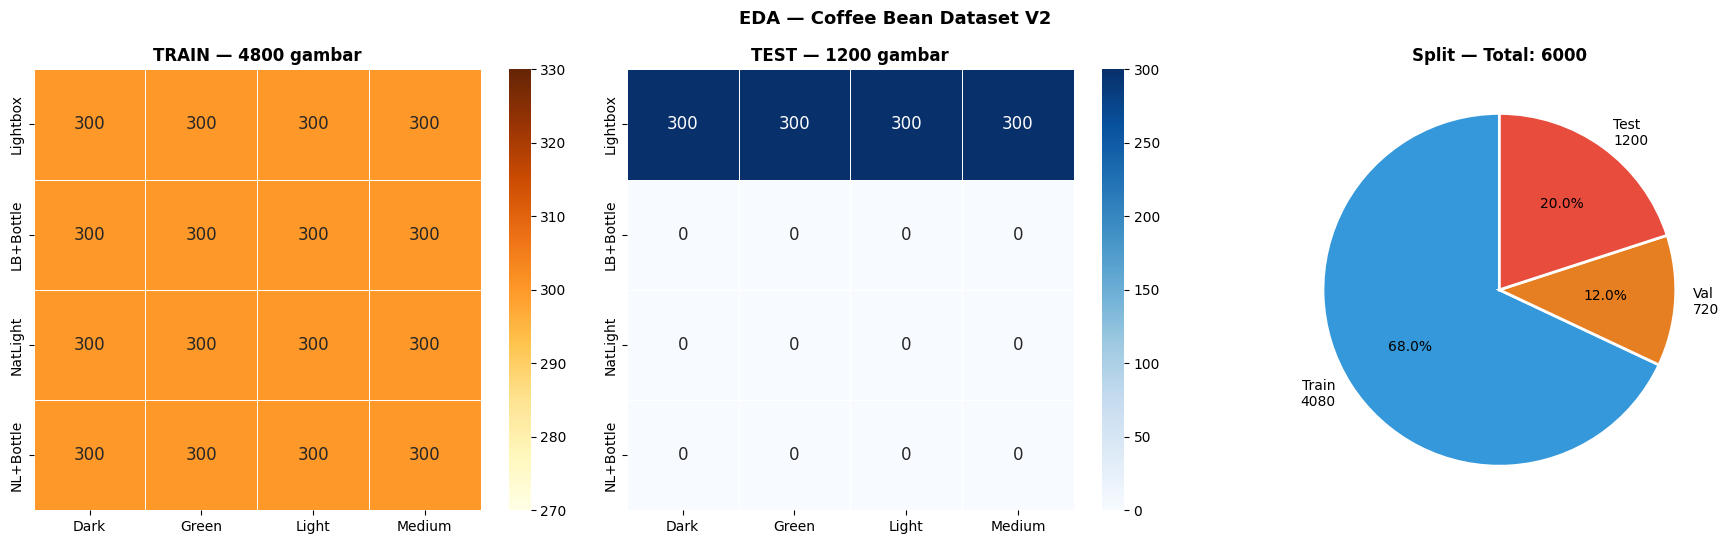

  eda_v5.png OK

[9] Model...

  Model                 feat_dim     Params  Input
  ------------------------------------------------------


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  EfficientNet-B0           1280     4.34M  224px


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

  MobileNetV3-Large         1280     4.53M  224px


...

model.safetensors:   0%|          | 0.00/20.9M [00:00<?, ?B/s]

  GhostNet-100              1280     4.23M  224px


model.safetensors:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

  RegNetY-400MF              440     4.02M  224px

[11] Training...

  EfficientNet-B0 | feat_dim=1280 | 224px
    Ep[01/35]  Train 66.62%  Val 96.94%  LR 2.9e-04  BEST
    Ep[02/35]  Train 75.20%  Val 99.44%  LR 2.7e-04  BEST
    Ep[03/35]  Train 77.23%  Val 100.00%  LR 2.4e-04  BEST
    Ep[05/35]  Train 79.32%  Val 100.00%  LR 1.5e-04
    Ep[10/35]  Train 80.11%  Val 100.00%  LR 3.0e-04
    Early stop @ ep 13

    Best Val: 100.00%  |  6.9 mnt

  MobileNetV3-Large | feat_dim=1280 | 224px


    Ep[01/35]  Train 69.15%  Val 99.03%  LR 2.9e-04  BEST
    Ep[02/35]  Train 76.79%  Val 100.00%  LR 2.7e-04  BEST
    Ep[05/35]  Train 82.12%  Val 100.00%  LR 1.5e-04
    Ep[10/35]  Train 84.90%  Val 100.00%  LR 3.0e-04
    Early stop @ ep 12

    Best Val: 100.00%  |  6.0 mnt

  MobileViT-XS | feat_dim=384 | 256px
    Ep[01/35]  Train 63.19%  Val 98.89%  LR 2.9e-04  BEST
    Ep[02/35]  Train 76.04%  Val 100.00%  LR 2.7e-04  BEST
    Ep[05/35]  Train 77.98%  Val 100.00%  LR 1.5e-04
    Ep[10/35]  Train 73.64%  Val 100.00%  LR 3.0e-04
    Early stop @ ep 12

    Best Val: 100.00%  |  8.1 mnt

  GhostNet-100 | feat_dim=1280 | 224px
    Ep[01/35]  Train 56.77%  Val 88.06%  LR 2.9e-04  BEST
    Ep[02/35]  Train 68.55%  Val 99.31%  LR 2.7e-04  BEST
    Ep[03/35]  Train 70.68%  Val 99.58%  LR 2.4e-04  BEST
    Ep[04/35]  Train 78.30%  Val 100.00%  LR 2.0e-04  BEST
    Ep[05/35]  Train 84.15%  Val 100.00%  LR 1.5e-04
    Ep[10/35]  Train 76.56%  Val 100.00%  LR 3.0e-04
    Early stop @ ep 

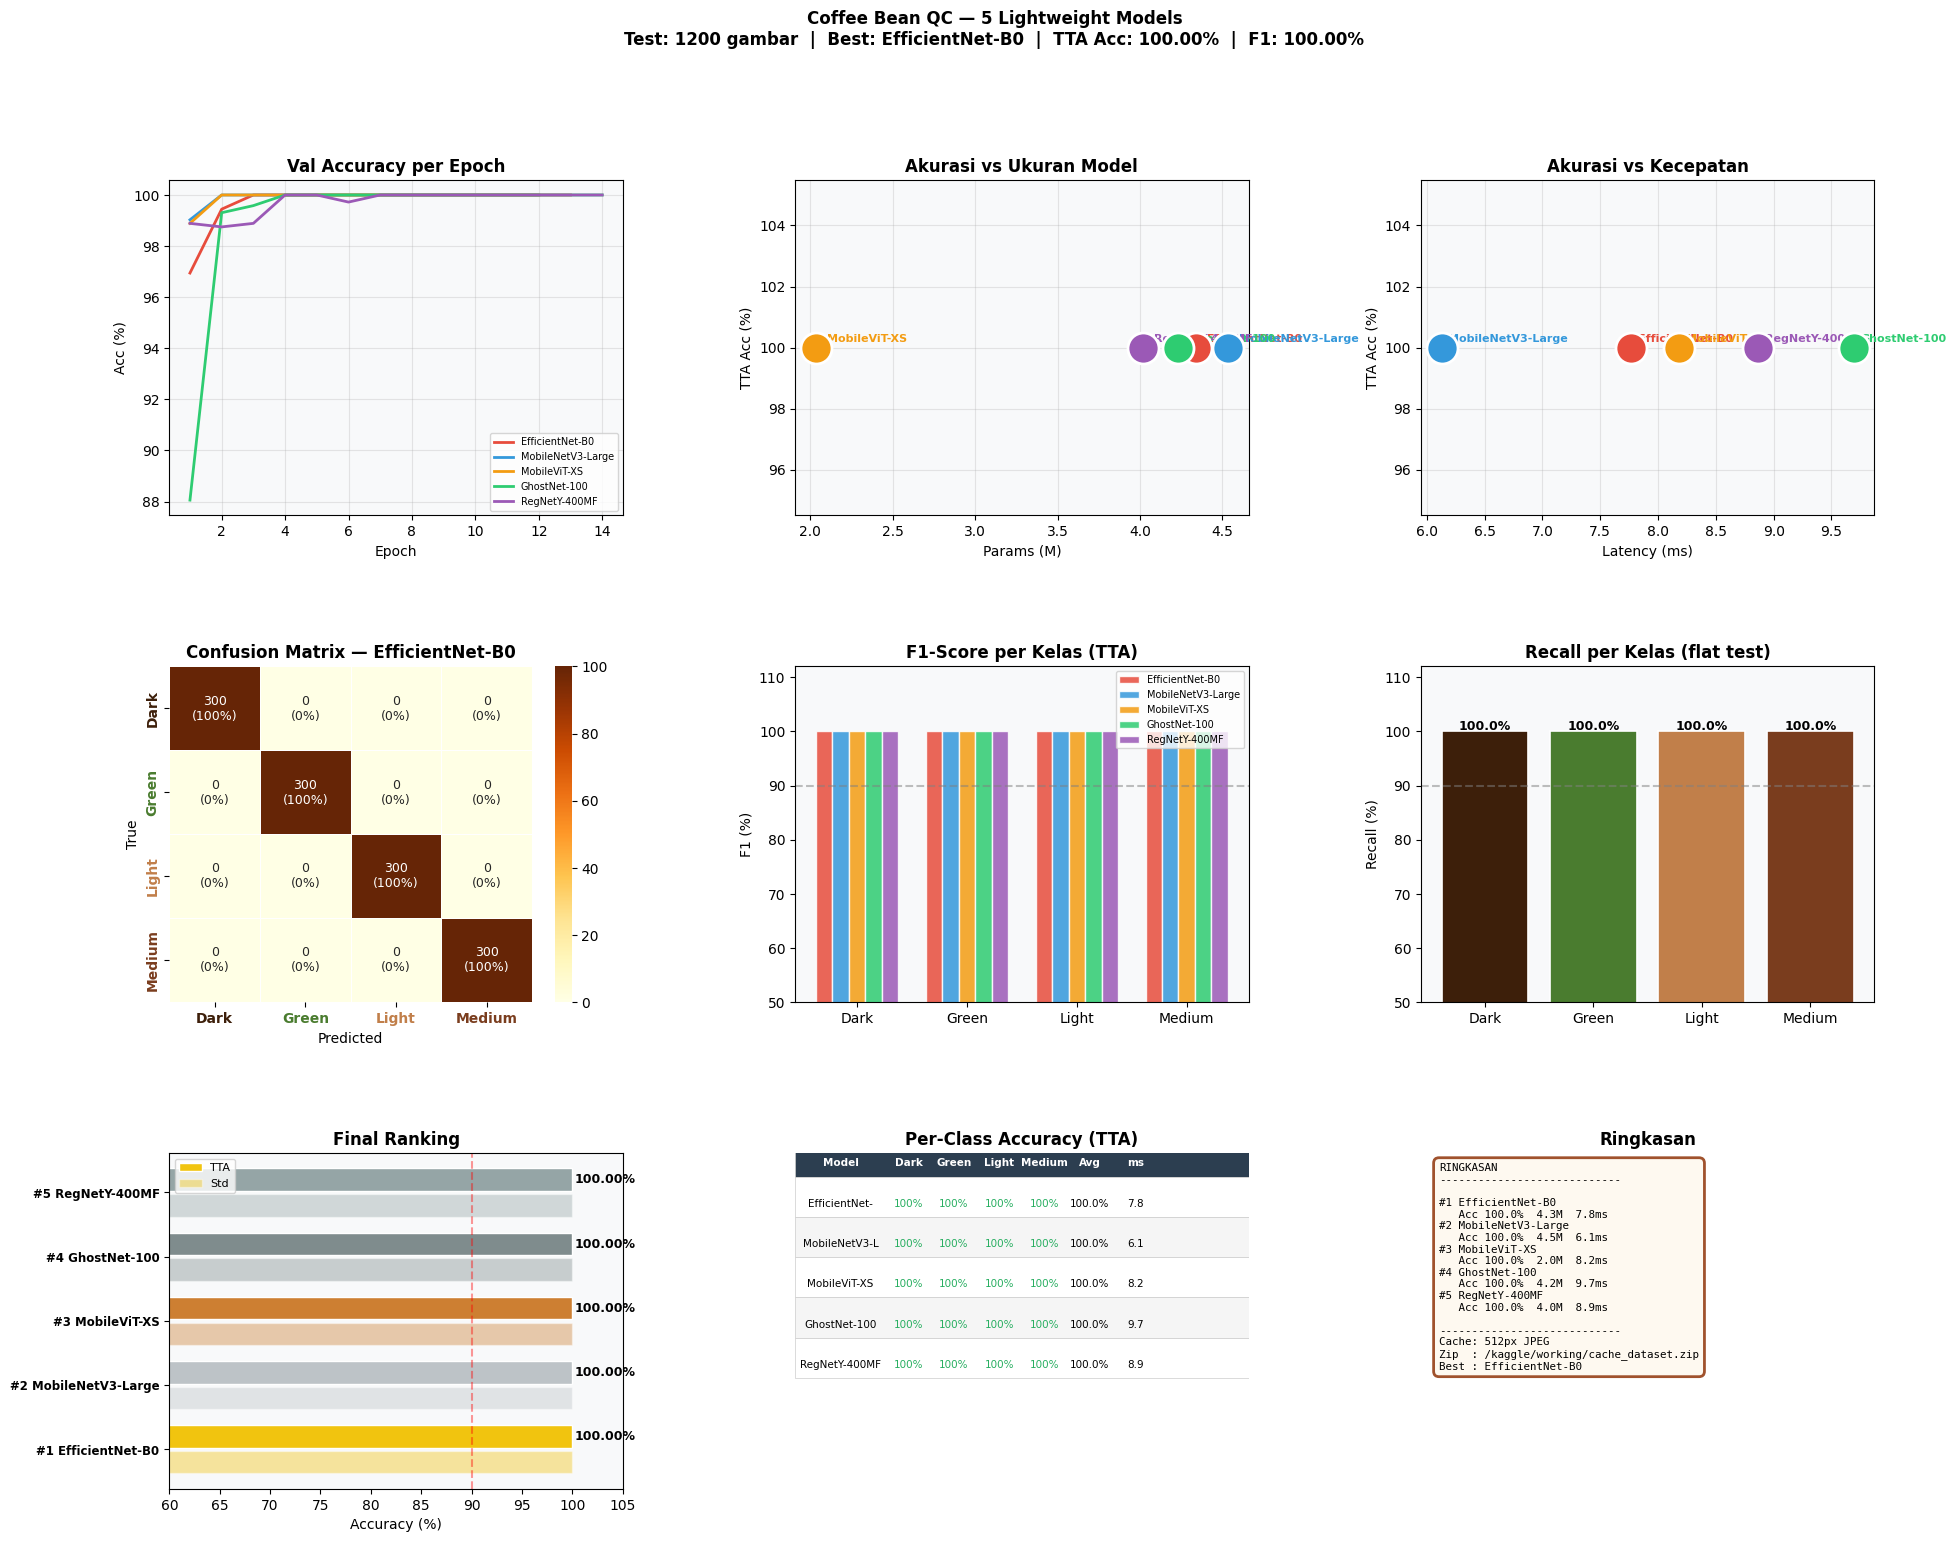

  scorecard_v5.png OK

[16] Grad-CAM...


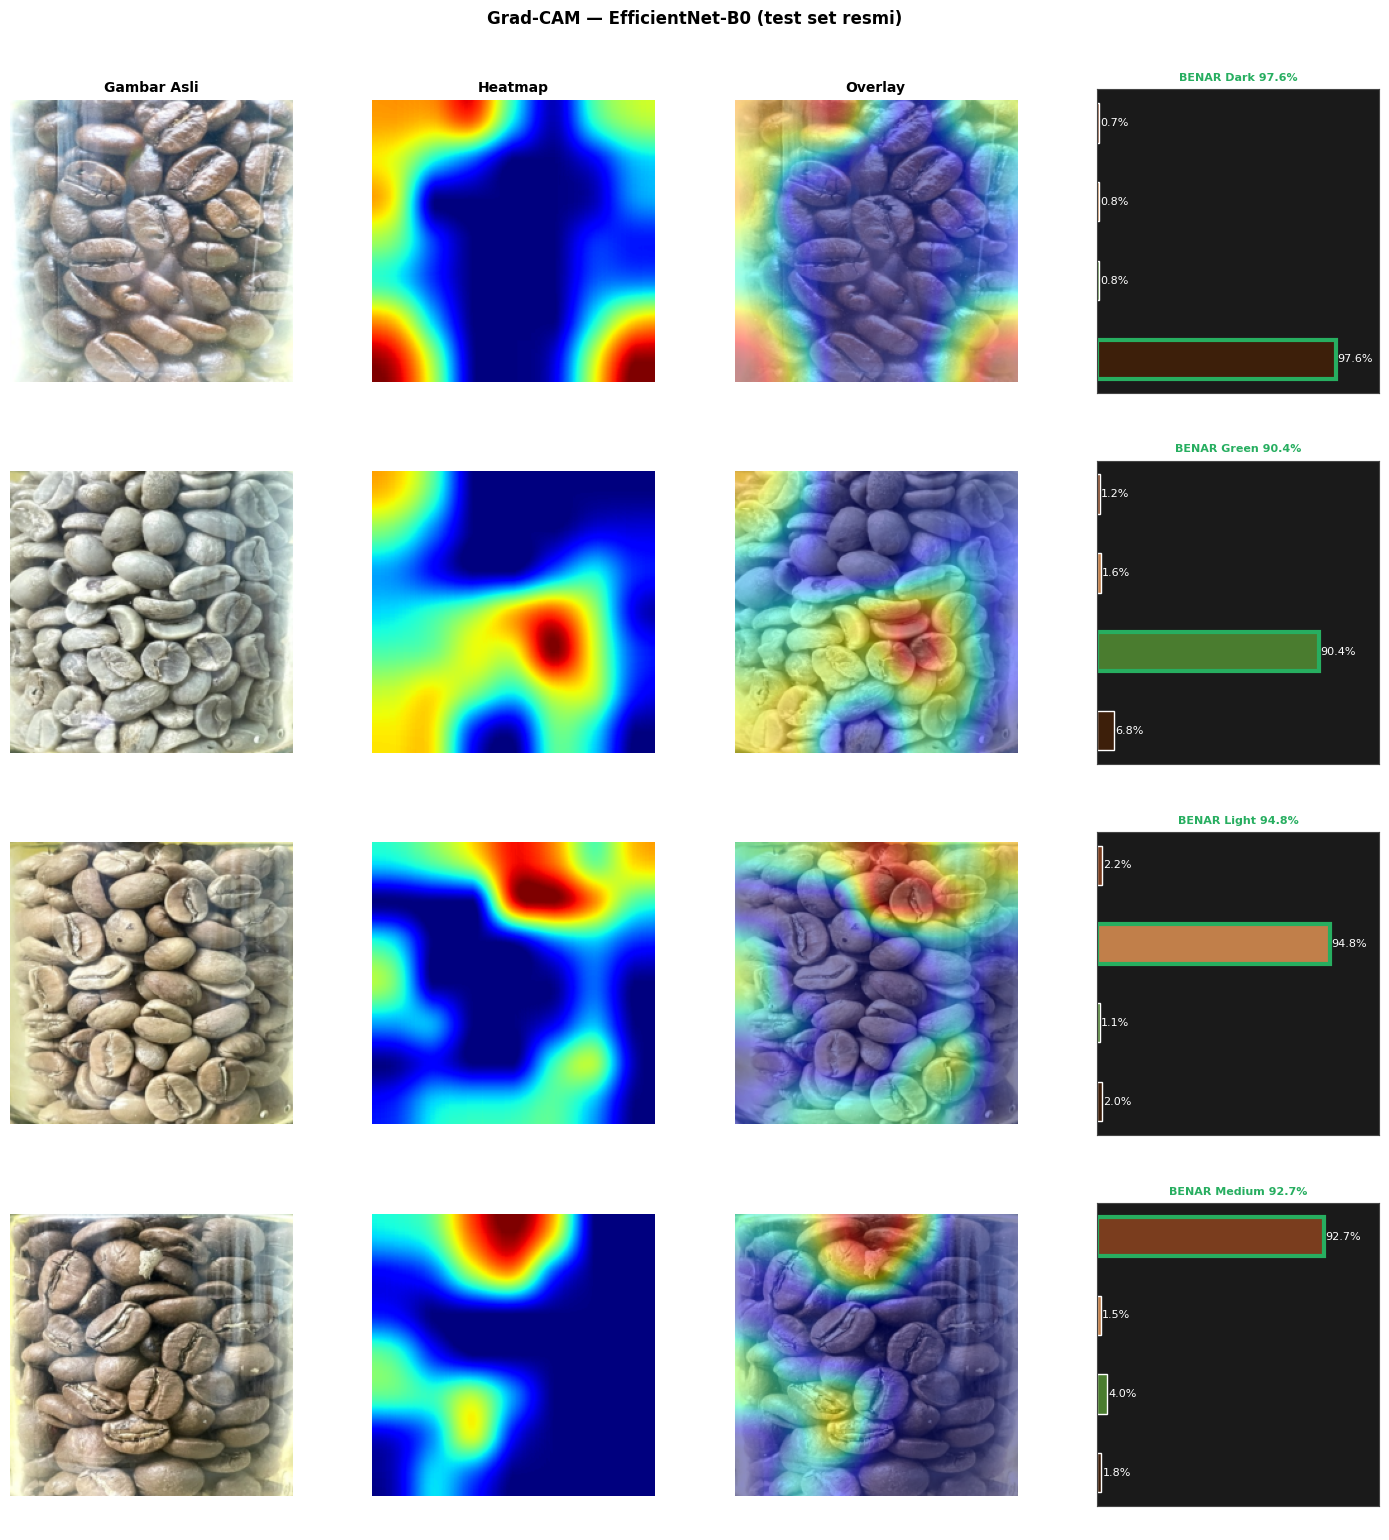

  gradcam_v5.png OK

  PIPELINE v5.5 SELESAI

  Model                 feat_dim   TTA Acc       F1   Params       ms
  ------------------------------------------------------------------
  #1 EfficientNet-B0         1280   100.00%  100.00%    4.3M    7.8ms
  #2 MobileNetV3-Large       1280   100.00%  100.00%    4.5M    6.1ms
  #3 MobileViT-XS             384   100.00%  100.00%    2.0M    8.2ms
  #4 GhostNet-100            1280   100.00%  100.00%    4.2M    9.7ms
  #5 RegNetY-400MF            440   100.00%  100.00%    4.0M    8.9ms

  Best     : EfficientNet-B0
  Zip cache: /kaggle/working/cache_dataset.zip

  Download zip dari Kaggle Output → upload ulang sebagai dataset
  → skip preprocessing, langsung training

  Cara pakai predict_roast (setelah pipeline selesai):
  result = predict_roast('/path/gambar.png')
  result = predict_roast('/path/gambar.png', model_name='MobileViT-XS')
  result = predict_roast('/path/gambar.png', use_tta=False)


In [ ]:
# ================================================================
# SELESAI
# ================================================================
print("\n" + "="*68)
print("  PIPELINE v5.5 SELESAI")
print("="*68)
print(f"\n  {'Model':<20} {'feat_dim':>9} {'TTA Acc':>9} {'F1':>8} {'Params':>8} {'ms':>8}")
print(f"  {'-'*66}")
for i,(nm,res) in enumerate(sorted(all_res_tta.items(),key=lambda x:-x[1]["oa"]),1):
    bm=all_benchmarks[nm]; fd=MODEL_CONFIGS[nm]["feat_dim"]
    print(f"  #{i} {nm:<18} {fd:>9} {res['oa']*100:>8.2f}% {np.mean(res['f1'])*100:>7.2f}% {bm['params_m']:>6.1f}M {bm['latency_ms']:>6.1f}ms")
print(f"\n  Best     : {best_model_name}")
print(f"  Zip cache: {CACHE_ZIP}")
print(f"\n  Download zip dari Kaggle Output → upload ulang sebagai dataset")
print(f"  → skip preprocessing, langsung training\n")
print(f"  Cara pakai predict_roast (setelah pipeline selesai):")
print(f"  result = predict_roast('/path/gambar.png')")
print(f"  result = predict_roast('/path/gambar.png', model_name='MobileViT-XS')")
print(f"  result = predict_roast('/path/gambar.png', use_tta=False)")
print("="*68)